# PIPELINE COMPLETO 

- Extracción de entidades nomnbradas y desambiguacion de contexto y rol institucional.  
- Exracción de relaciones. 
- EDA basico para ver como ha funcionado. 
- Creación de las reglas de calidad para crear y etiquetar automaticamente el corpus Silver. 
- Creación de un pipeline Teacher-Learner para el fine tunning y la creación de un grafo de conocimiento al que preguntar. 

## - Extracción de entidades nomnbradas y desambiguacion de contexto y rol institucional.  


In [ ]:
import json
import spacy
from spacy.matcher import PhraseMatcher
import unicodedata
import pandas as pd
from rapidfuzz import process, fuzz
import re
from collections import defaultdict
import os
from openai import OpenAI
from pydantic import BaseModel, Field
from enum import Enum

os.environ["OPENAI_API_KEY"] = ""
client = OpenAI()

# 1. Función de normalización 
def normalizar_texto(texto):
    if not texto or not isinstance(texto, str): return ""
    texto = texto.lower()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return texto.strip()

# Cargar spaCy vacio para tokenizar
nlp_fast = spacy.blank("es")
nlp_ner = spacy.load("es_core_news_sm")

/Users/joseadiazg/Desktop/UGR/ESTANCIAS/OVIEDO/ codigo/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Creamos las colecciones para comenzar a procesar. 

In [5]:
grupos = pd.read_json("./datos/grupos_detalle.json")
centros = pd.read_json("./datos/centros_detalle.json")
noticias = pd.read_json("./datos/noticias_uniovi.json")

diccionario_investigadores = {}

# Cream os el diccionario con Grupos y su contexto
for _, grupo in grupos.iterrows():
    departamento = grupo.get("departamento", "No especificado")
    area = grupo.get("area_conocimiento", "No especificada")
    nombre_grupo = grupo.get("nombre_grupo", "")

    for miembro in grupo.get("miembros", []) + grupo.get("colaboradores", []):
        if isinstance(miembro, dict) and "url_detalle" in miembro:
            id_unico = miembro["url_detalle"]
            nombre_oficial = miembro["nombre"]

            if id_unico not in diccionario_investigadores:
                diccionario_investigadores[id_unico] = {
                    "nombre_oficial": nombre_oficial,
                    "departamento": departamento,
                    "area_conocimiento": area,
                    "grupos": [nombre_grupo] if nombre_grupo else [],
                    "centros": []
                }
            else:
                if nombre_grupo and nombre_grupo not in diccionario_investigadores[id_unico]["grupos"]:
                    diccionario_investigadores[id_unico]["grupos"].append(nombre_grupo)

# Enriquecemos con Centros
for _, centro in centros.iterrows():
    nombre_centro = centro.get("nombre_centro", "")
    if "investigadores" in centro and isinstance(centro["investigadores"], list):
        for inv in centro.get("investigadores", []):
            if isinstance(inv, dict) and "url_detalle" in inv:
                id_unico = inv["url_detalle"]
                if id_unico in diccionario_investigadores:
                    if nombre_centro and nombre_centro not in diccionario_investigadores[id_unico]["centros"]:
                        diccionario_investigadores[id_unico]["centros"].append(nombre_centro)
                else:
                    diccionario_investigadores[id_unico] = {
                        "nombre_oficial": inv["nombre"],
                        "departamento": "No especificado",
                        "area_conocimiento": "No especificada",
                        "grupos": [],
                        "centros": [nombre_centro]
                    }

print(f"Indexados {len(diccionario_investigadores)} investigadores con su contexto (centros de trabajo, departamentos etc para poder desambiguar en caso necesario).")

Indexados 2285 investigadores con su contexto (centros de trabajo, departamentos etc para poder desambiguar en caso necesario).


Siguiente paso, vamos a crear los alias para los investigadores para la localizacion difusa y la localizacion por nombres deterministica. 

In [ ]:
def generar_alias_validos(nombre_completo):
    """Genera alias obligando a que incluyan siempre un apellido,
    contemplando la omisión del primer nombre en nombres compuestos."""

    nombre_clean = normalizar_texto(nombre_completo).upper()

    # Limpiamos conectores comunes que rompen el conteo de palabras
    palabras_crudas = nombre_clean.split()
    palabras = [p for p in palabras_crudas if p not in ["DE", "LA", "LAS", "DEL", "LOS", "Y"]]

    alias = set([nombre_clean]) # El nombre completo original siempre entra

    # CASO: 4 palabras (Nombre1, Nombre2, Apellido1, Apellido2)
    # Ejemplo: SUSANA IRENE DIAZ RODRIGUEZ
    if len(palabras) == 4:
        n1, n2, a1, a2 = palabras
        alias.update([
            f"{n1} {n2} {a1}",       # SUSANA IRENE DIAZ
            f"{n1} {a1} {a2}",       # SUSANA DIAZ RODRIGUEZ
            f"{n2} {a1} {a2}",       # IRENE DIAZ RODRIGUEZ
            f"{n1} {a1}",            # SUSANA DIAZ
            f"{n2} {a1}",            # IRENE DIAZ
            f"{a1} {a2}"             # DIAZ RODRIGUEZ
        ])

    # CASO: 3 palabras (Nombre, Apellido1, Apellido2)
    # Ejemplo: IRENE DIAZ MARTINEZ
    elif len(palabras) == 3:
        n, a1, a2 = palabras
        alias.update([
            f"{n} {a1}",             # IRENE DIAZ
            f"{a1} {a2}"             # DIAZ MARTINEZ
        ])

    # CASO: 5 o más palabras (para Nombres muy largos)
    elif len(palabras) >= 5:
        a1, a2 = palabras[-2], palabras[-1]
        n1, n2 = palabras[0], palabras[1]
        alias.update([
            f"{n1} {a1} {a2}",
            f"{n2} {a1} {a2}",
            f"{n1} {a1}",
            f"{n2} {a1}",
            f"{a1} {a2}"
        ])

    return list(alias)

mapa_alias_a_ids = defaultdict(list)
lista_alias_norm = []

for id_unico, datos in diccionario_investigadores.items():
    alias_validos = generar_alias_validos(datos["nombre_oficial"])
    for a in alias_validos:
        alias_norm = normalizar_texto(a)
        mapa_alias_a_ids[alias_norm].append(id_unico)
        lista_alias_norm.append(alias_norm)

lista_alias_norm = list(set(lista_alias_norm)) 

# Poblamos el PhraseMatcher exacto
matcher = PhraseMatcher(nlp_fast.vocab, attr="LOWER")
for alias_norm in mapa_alias_a_ids.keys():
    matcher.add(alias_norm, [nlp_fast.make_doc(alias_norm)])

print(f"Generados {len(mapa_alias_a_ids)} alias seguros para búsqueda (incluyendo segundos nombres con apellidos).")

Generados 9015 alias seguros para búsqueda (incluyendo segundos nombres con apellidos).


In [7]:

def detectar_candidatos(texto_completo):
    texto_norm = normalizar_texto(texto_completo)
    ids_encontradas = set()

    # 1. Match Exacto con PhraseMatcher
    doc_fast = nlp_fast(texto_norm)
    coincidencias = matcher(doc_fast)
    for match_id, start, end in coincidencias:
        alias_encontrado = nlp_fast.vocab.strings[match_id]
        for i in mapa_alias_a_ids[alias_encontrado]:
            ids_encontradas.add(i)

    # 2. Match Difuso con NER
    doc_ner = nlp_ner(texto_completo)
    for entidad in doc_ner.ents:
        if entidad.label_ == "PER":
            entidad_norm = normalizar_texto(entidad.text)
            if len(entidad_norm.split()) > 1: # Ignorar una sola palabra
                resultado = process.extractOne(
                    entidad_norm,
                    lista_alias_norm,
                    scorer=fuzz.token_sort_ratio
                )
                if resultado and resultado[1] > 85:
                    mejor_alias = resultado[0]
                    for i in mapa_alias_a_ids[mejor_alias]:
                        ids_encontradas.add(i)

    # 3. Construir lista de contexto para el LLM
    candidatos_contexto = []
    for id_url in ids_encontradas:
        info = diccionario_investigadores[id_url]
        candidatos_contexto.append({
            "id_url": id_url,
            "nombre": info["nombre_oficial"],
            "departamento": info["departamento"],
            "grupos": info["grupos"]
        })

    return candidatos_contexto

## Exracción de relaciones y desambiguacion. 

In [8]:

class RolMencion(str, Enum):
    INVESTIGADOR = "INVESTIGADOR" # Habla de su ciencia, papers, proyectos, descubrimientos.
    INSTITUCIONAL = "INSTITUCIONAL" # Habla como vicerrector/a, decano/a, inauguraciones, política universitaria.
    IRRELEVANTE = "IRRELEVANTE" # Mención tangencial o error de desambiguación.

class TipoRelacion(str, Enum):
    LIDERA = "LIDERA"
    INVESTIGA_SOBRE = "INVESTIGA_SOBRE"
    DESARROLLA = "DESARROLLA"
    COLABORA_EN = "COLABORA_EN"

class AnalisisCandidato(BaseModel):
    investigador_id: str = Field(description="URL/ID exacta del candidato.")
    rol_detectado: RolMencion = Field(description="Rol en el que actúa la persona en ESTA noticia concreta.")
    justificacion: str = Field(description="Breve motivo por el cual se le asigna ese rol basándose en el texto.")

class TripletaInvestigacion(BaseModel):
    investigador_id: str = Field(description="URL/ID exacta seleccionada de la lista de CANDIDATOS. Debe tener rol INVESTIGADOR.")
    relacion: TipoRelacion = Field(description="Verbo de relación normalizado.")
    topico_o_concepto: str = Field(description="Área, tecnología o concepto específico puramente científico/técnico.")
    evidencia: str = Field(description="Cita textual corta que respalda la extracción.")

class ExtraerNoticiaResponse(BaseModel):
    analisis_roles: list[AnalisisCandidato] = Field(description="Evaluación del rol de CADA candidato detectado.")
    tripletas: list[TripletaInvestigacion] = Field(description="Tripletas extraídas SOLO para los candidatos con rol INVESTIGADOR.")

In [9]:
def extraer_con_llm(titulo, resumen, cuerpo, candidatos):
    prompt_sistema = """
    Eres un experto en extracción de información para un Grafo de Conocimiento Científico.
    Tu tarea consta de DOS fases estrictas:

    FASE 1: CLASIFICACIÓN DE ROL (Desacoplamiento)
    Evalúa a cada candidato en la lista proporcionada. Determina si en esta noticia se le menciona en calidad de:
    - INVESTIGADOR: Presentando un paper, liderando un proyecto científico, explicando tecnología.
    - INSTITUCIONAL: Actuando como Vicerrector/a, Rector/a, inaugurando eventos, firmando acuerdos, política universitaria.
    - IRRELEVANTE: Si la mención es tangencial o es un falso positivo.

    FASE 2: EXTRACCIÓN DE TRIPLETAS
    Extrae relaciones (LIDERA, INVESTIGA_SOBRE, DESARROLLA, COLABORA_EN) **ÚNICAMENTE** para los candidatos clasificados como 'INVESTIGADOR'.
    Ignora por completo a los candidatos con rol 'INSTITUCIONAL' o 'IRRELEVANTE' para la creación de tripletas. No crees tripletas sobre gestión administrativa (ej. "LIDERA -> la universidad").

    REGLA DE DESAMBIGUACIÓN ESTRICTA:
    1. Usa ÚNICAMENTE las `id_url` proporcionadas en los CANDIDATOS.
    2. Apóyate en los "departamentos" y "grupos" de los candidatos para desambiguar si el texto menciona conceptos relacionados con su área.
    """

    prompt_usuario = f"""
    --- NOTICIA ---
    Título: {titulo}
    Texto: {resumen} {cuerpo}

    --- CANDIDATOS DETECTADOS ---
    {json.dumps(candidatos, ensure_ascii=False, indent=2)}
    """

    completion = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": prompt_sistema},
            {"role": "user", "content": prompt_usuario}
        ],
        response_format=ExtraerNoticiaResponse,
        temperature=0.0
    )
    return completion.choices[0].message.parsed

## CREACION DE REGLAS PARA LA CREACION DEL DATASET DE ETIQUETAS SILVER

In [10]:

def normalizar(texto):
    if not texto or not isinstance(texto, str): 
        return ""
    texto = texto.lower()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return re.sub(r'[^\w\s]', '', texto).strip()

def validar_soporte_lexico(topico, evidencia):
    """Regla 3 del paper: Verifica solapamiento de al menos una palabra clave entre tópico y evidencia."""
    tokens_topico = [t for t in normalizar(topico).split() if len(t) > 3]
    evidencia_norm = normalizar(evidencia)
    if not tokens_topico: 
        return True  # mantenemos acrónimos o términos muy cortos (ej. IA, 5G)
    return any(token in evidencia_norm for token in tokens_topico)

def construir_dataset_silver(df_tripletas, df_roles, candidatos_por_noticia, diccionario_investigadores):
    RELACIONES_VALIDAS = {"LIDERA", "INVESTIGA_SOBRE", "DESARROLLA", "COLABORA_EN"}
    
    # Prevenir duplicados en df_roles antes de fusionar
    df_roles_clean = df_roles[['investigador_id', 'noticia_index', 'rol']].drop_duplicates(
        subset=['investigador_id', 'noticia_index']
    )

    # Fusionar tripletas con roles (Regla 4 del paper)
    df_merged = df_tripletas.merge(
        df_roles_clean, 
        on=['investigador_id', 'noticia_index'], 
        how='left'
    )

    tripletas_silver = []

    for _, row in df_merged.iterrows():
        # REGLA 4: Role Consistency
        if row.get('rol') != 'INVESTIGADOR':
            continue

        # REGLA 2: Closed-schema Relation Validity
        if row.get('relacion') not in RELACIONES_VALIDAS:
            continue

        # REGLA 3: Evidence-Topic Lexical Support
        if not validar_soporte_lexico(str(row.get('topico', '')), str(row.get('evidencia', ''))):
            continue

        # REGLA 1 & 6: Researcher Selection & Context Compatibility
        noticia_idx = row['noticia_index']
        candidatos_noticia = candidatos_por_noticia.get(noticia_idx, [])
        info_inv = diccionario_investigadores.get(row['investigador_id'], {})
        
        #  comprobar mención explicita si hay densidad de candidatos (> 3)
        tokens_nombre = [t for t in normalizar(info_inv.get('nombre_oficial', '')).split() if len(t) > 2]
        evidencia_norm = normalizar(str(row.get('evidencia', '')))
        mencionado_en_evidencia = any(t in evidencia_norm for t in tokens_nombre)
        
        grounded = (len(candidatos_noticia) <= 3) or mencionado_en_evidencia
        if not grounded:
            continue

        tripletas_silver.append(row)

    # caso de que no haya ninguna
    if not tripletas_silver:
        print("No se encontraron tripletas que cumplan los criterios de filtro.")
        return pd.DataFrame(columns=df_tripletas.columns)

    df_silver = pd.DataFrame(tripletas_silver)

    # REGLA 5 del paper: Internal Coherence
    df_silver = df_silver.drop_duplicates(
        subset=['investigador_id', 'relacion', 'topico', 'noticia_index']
    ).reset_index(drop=True)

    # Limpieza final de columnas
    if 'rol' in df_silver.columns:
        df_silver = df_silver.drop(columns=['rol'])

    return df_silver

In [11]:
todas_las_tripletas = []
todos_los_roles = []
candidatos_por_noticia = {} 

noticias_a_procesar = noticias


for index, row in noticias_a_procesar.iterrows():
    texto_completo = f"{row['titulo']} {row['resumen']} {row['noticia']}"

    candidatos = detectar_candidatos(texto_completo)

    if not candidatos:
        continue

    # Guardamos los candidatos en el diccionario usando el índice de la noticia
    candidatos_por_noticia[index] = candidatos

    print(f"\n[{index}] Noticia: {row['titulo'][:50]}... ({len(candidatos)} candidatos)")

    try:
        # Extracción y Clasificación con el LLM
        resultado = extraer_con_llm(row['titulo'], row['resumen'], row['noticia'], candidatos)

        # Guardar roles para posterior análisis y construcción del dataset Silver
        for analisis in resultado.analisis_roles:
            nombre = diccionario_investigadores.get(analisis.investigador_id, {}).get('nombre_oficial', 'Desconocido')
            todos_los_roles.append({
                "investigador_id": analisis.investigador_id,
                "nombre": nombre,
                "rol": analisis.rol_detectado.value,
                "justificacion": analisis.justificacion,
                "noticia_index": index
            })

        # Guardar Tripletas para analisis de tripletas y construcción del dataset Silver
        for t in resultado.tripletas:
            if t.investigador_id in diccionario_investigadores:
                nombre = diccionario_investigadores[t.investigador_id]['nombre_oficial']
                todas_las_tripletas.append({
                    "investigador_id": t.investigador_id,
                    "nombre_investigador": nombre,
                    "relacion": t.relacion.value,
                    "topico": t.topico_o_concepto,
                    "evidencia": t.evidencia,
                    "noticia_index": index
                })
                
    except Exception as e:
        print(f"Error procesando noticia {index}: {e}")

# pasamos a data frames para guardar y tener todo en un formato tabular 
df_tripletas = pd.DataFrame(todas_las_tripletas)
df_roles = pd.DataFrame(todos_los_roles)

# construimos del dataset
df_silver = construir_dataset_silver(
    df_tripletas, 
    df_roles, 
    candidatos_por_noticia, 
    diccionario_investigadores
)

print(f"\nProceso completado:")
print(f" - Tripletas iniciales LLM: {len(df_tripletas)}")
print(f" - Tripletas finales Silver: {len(df_silver)}")

df_silver.to_csv("dataset_silver_tripletas.csv", index=False)


[0] Noticia: La nueva Junta Rectora de CRUE se reúne con el pre... (1 candidatos)

[1] Noticia: La Universidad de Oviedo reconstruye los orígenes ... (2 candidatos)

[2] Noticia: La Universidá Asturiana de Branu incorpora la inte... (2 candidatos)

[3] Noticia: El grupo Llabor de la Universidad de Oviedo regres... (1 candidatos)

[5] Noticia: Los Picos de Europa esconden un ‘amortiguador’ geo... (13 candidatos)

[6] Noticia: La Real Sociedad Española de Física premia la tesi... (11 candidatos)

[8] Noticia: Treinta estudiantes de la Universidad de Oviedo co... (3 candidatos)

[9] Noticia: La Universidad de Oviedo muestra sus buenas prácti... (10 candidatos)

[10] Noticia: La Comisión Europea asegura la financiación para l... (1 candidatos)

[12] Noticia: El primer estudio de la Cátedra Universitaria de D... (2 candidatos)

[14] Noticia: La Universidad de Oviedo reconoce la trayectoria d... (12 candidatos)

[16] Noticia: La Universidad de Oviedo reúne a especialistas int... (3 candidat

## EDA basico para ver como ha funcionado. 

Vamos a sacar algunos graficos para comprobar que funciona bien.

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_35902/359920823.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


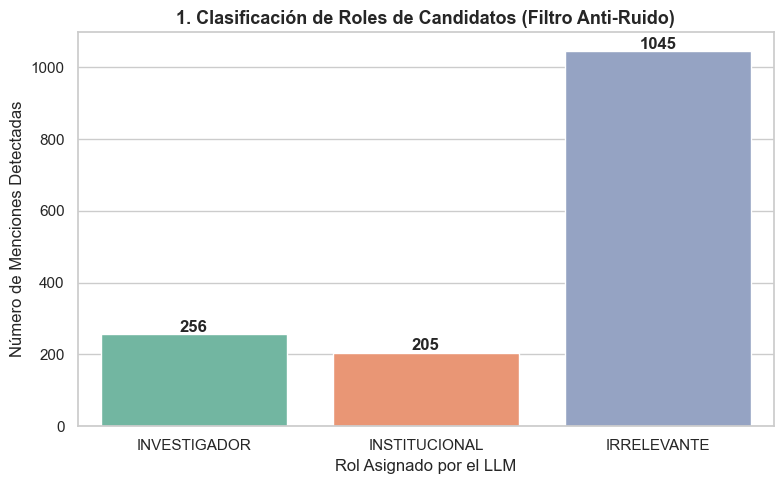

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_35902/359920823.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


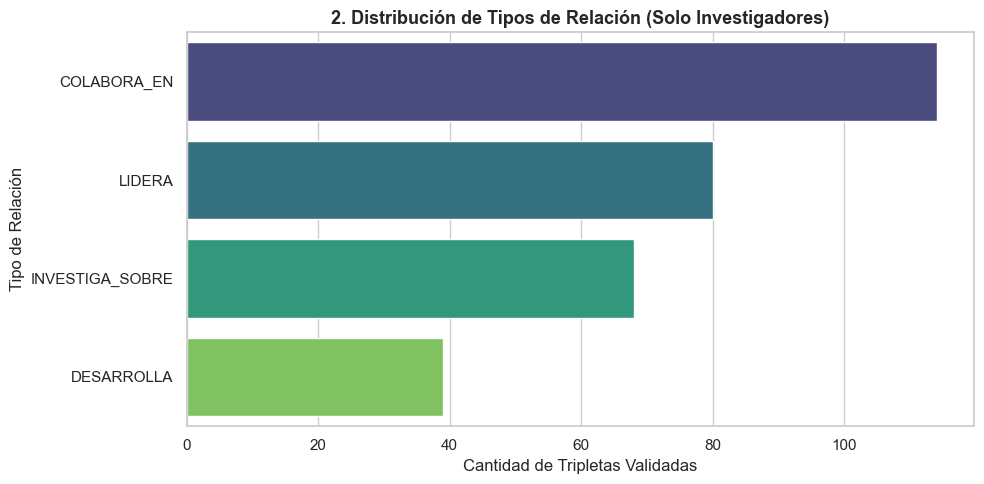

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_35902/359920823.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


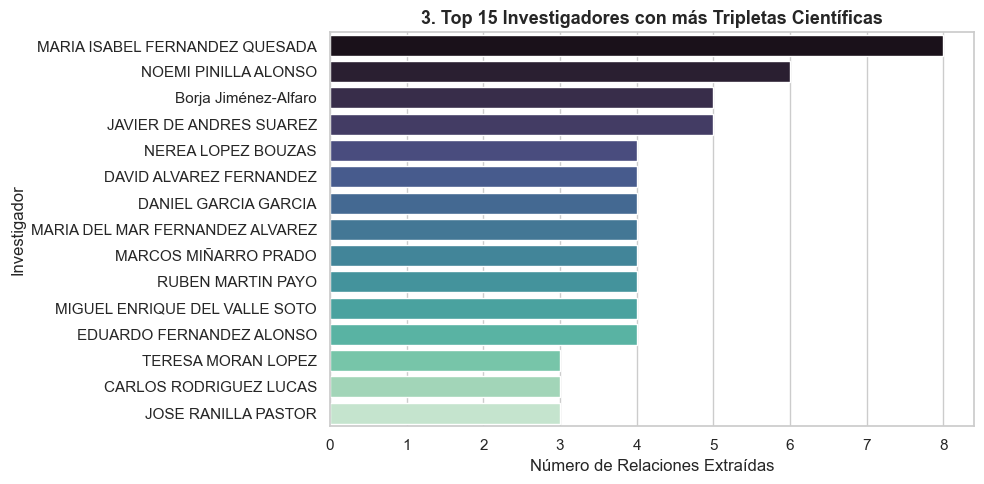

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_35902/359920823.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


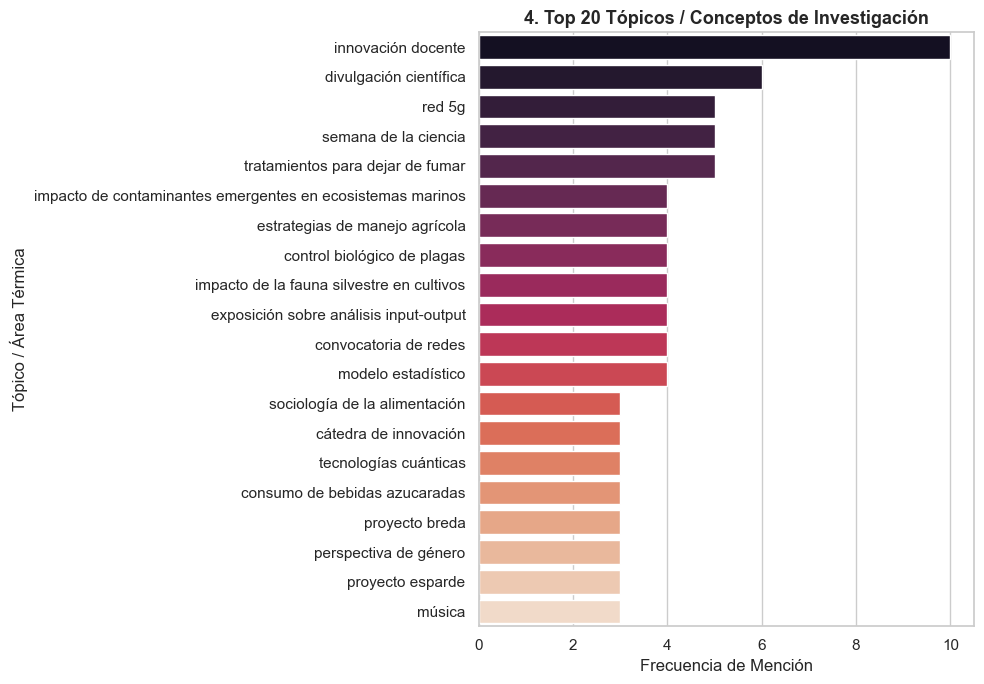

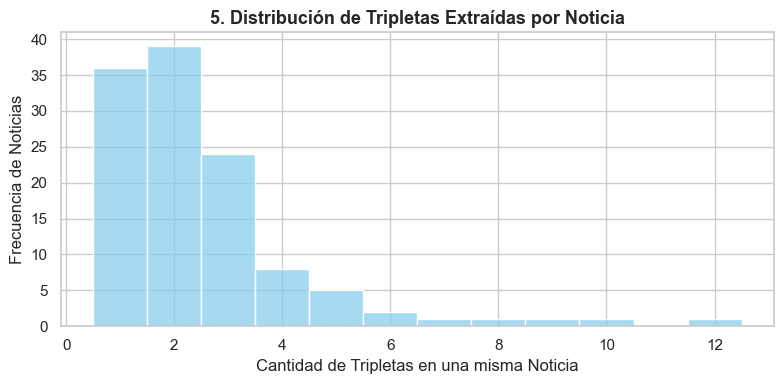

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuración global de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Convertir a DataFrames si aún no lo están
df_roles = pd.DataFrame(todos_los_roles)
df_tripletas = pd.DataFrame(todas_las_tripletas)

# ---Distribución de Roles Detectados ---
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_roles,
    x='rol',
    order=['INVESTIGADOR', 'INSTITUCIONAL', 'IRRELEVANTE'],
    palette="Set2"
)
plt.title("1. Clasificación de Roles de Candidatos (Filtro Anti-Ruido)", fontsize=13, fontweight='bold')
plt.xlabel("Rol Asignado por el LLM")
plt.ylabel("Número de Menciones Detectadas")

# Añadir etiquetas con el número exacto sobre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

# ---  Distribución de Relaciones Extraídas ---
plt.figure()
sns.countplot(
    data=df_tripletas,
    y='relacion',
    order=df_tripletas['relacion'].value_counts().index,
    palette="viridis"
)
plt.title("2. Distribución de Tipos de Relación (Solo Investigadores)", fontsize=13, fontweight='bold')
plt.xlabel("Cantidad de Tripletas Validadas")
plt.ylabel("Tipo de Relación")
plt.tight_layout()
plt.show()

# --- 3. TOP 15 INVESTIGADORES CIENTÍFICOS MÁS ACTIVOS ---
plt.figure()
top_investigadores = df_tripletas['nombre_investigador'].value_counts().head(15)
sns.barplot(
    x=top_investigadores.values, 
    y=top_investigadores.index, 
    palette="mako"
)
plt.title("3. Top 15 Investigadores con más Tripletas Científicas", fontsize=13, fontweight='bold')
plt.xlabel("Número de Relaciones Extraídas")
plt.ylabel("Investigador")
plt.tight_layout()
plt.show()

# --- 4. TOP 20 TÓPICOS DE INVESTIGACIÓN MÁS FRECUENTES ---
plt.figure(figsize=(10, 7))
topicos_limpios = df_tripletas['topico'].str.lower().str.strip().value_counts().head(20)
sns.barplot(
    x=topicos_limpios.values, 
    y=topicos_limpios.index, 
    palette="rocket"
)
plt.title("4. Top 20 Tópicos / Conceptos de Investigación", fontsize=13, fontweight='bold')
plt.xlabel("Frecuencia de Mención")
plt.ylabel("Tópico / Área Térmica")
plt.tight_layout()
plt.show()

# --- 5. EFICIENCIA DE EXTRACCIÓN: Tripletas por Noticia ---
plt.figure(figsize=(8, 4))
tripletas_por_noticia = df_tripletas['noticia_index'].value_counts()
sns.histplot(tripletas_por_noticia, discrete=True, kde=False, color="skyblue")
plt.title("5. Distribución de Tripletas Extraídas por Noticia", fontsize=13, fontweight='bold')
plt.xlabel("Cantidad de Tripletas en una misma Noticia")
plt.ylabel("Frecuencia de Noticias")
plt.tight_layout()
plt.show()

Hemos conseguido obtener buenos resultados, al menos ya no aparecen tripletas que no estan relacionadas con institucional, pero hay muchas menciones irrelevantes, creo que deberiamos analizar que pasa aqui, proque hay tantas irrelevantes y hacer un analisis un poco mas exhaustivo, pero ahora de momento vamos a dejar el pipelie completo porque auqu.  

## VISUALIZACION Y COMPRACION DEL DATASET SILVER Y GENERAL PARA EL PAPER

In [ ]:
registros_pipeline = []
for idx, row in noticias.iterrows():
    cands_raw = candidatos_por_noticia.get(idx, [])
    cands_filt = [c for c in cands_raw if c.get("id_url") in df_roles[df_roles['noticia_index'] == idx]['investigador_id'].values] if not df_roles.empty else []
    
    trip_raw_count = len(df_tripletas[df_tripletas['noticia_index'] == idx]) if not df_tripletas.empty else 0
    trip_acep_count = len(df_silver[df_silver['noticia_index'] == idx]) if not df_silver.empty else 0

    status = "ok" if trip_acep_count > 0 else ("sin_candidatos" if not cands_raw else "sin_tripletas_tras_filtro")

    registros_pipeline.append({
        "news_id": idx,
        "titulo": row['titulo'],
        "status": status,
        "num_candidatos_raw": len(cands_raw), # Detectados con PhraseMatcher
        "num_candidatos_filtrados": len(cands_filt), # Clasificados con rol en el LLM
        "num_tripletas_raw": trip_raw_count,
        "num_tripletas_aceptadas": trip_acep_count
    })

df_noticias_pipeline = pd.DataFrame(registros_pipeline)

# 2. Mapear Tripletas Raw
df_tripletas_raw = df_tripletas.rename(columns={
    "noticia_index": "news_id",
    "topico": "topico_textual"
}).assign(
    verbo_superficie=df_tripletas['relacion'],
    topico_normalizado=df_tripletas['topico'].apply(normalizar)
)

# 3. Mapear Tripletas Aceptadas / Silver
df_tripletas_aceptadas = df_silver.rename(columns={
    "noticia_index": "news_id",
    "topico": "topico_textual"
}).assign(
    verbo_superficie=df_silver['relacion'],
    topico_normalizado=df_silver['topico'].apply(normalizar),
    topico_canonico=df_silver['topico'].str.lower().str.strip() # Canonización temporal previa al catálogo
)

df_silver = df_tripletas_aceptadas.copy()

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_35902/2570132187.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


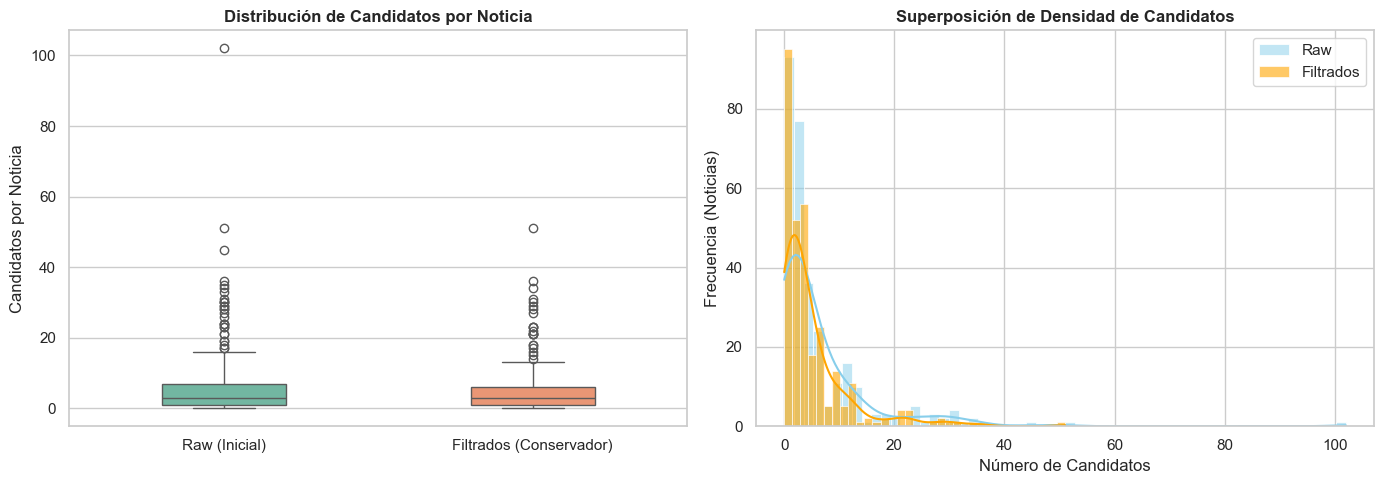

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_35902/2570132187.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_rel = sns.countplot(


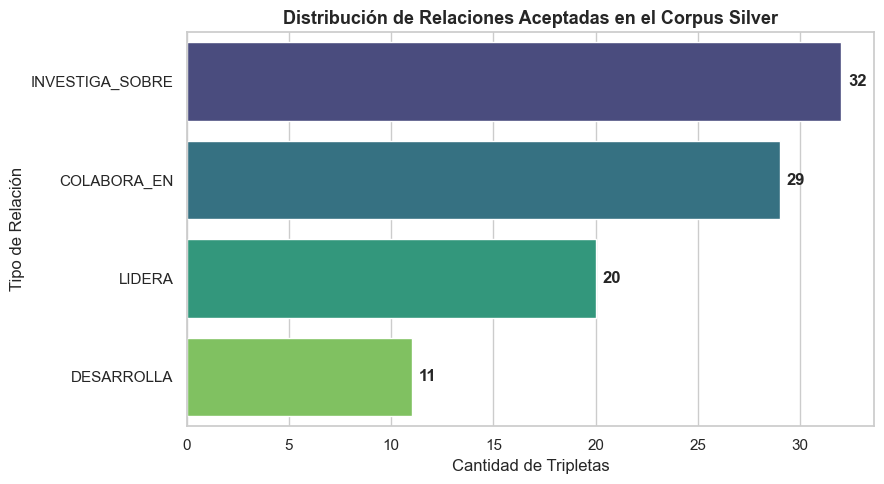

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_35902/2570132187.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_inv.values, y=top_inv.index, palette="mako")


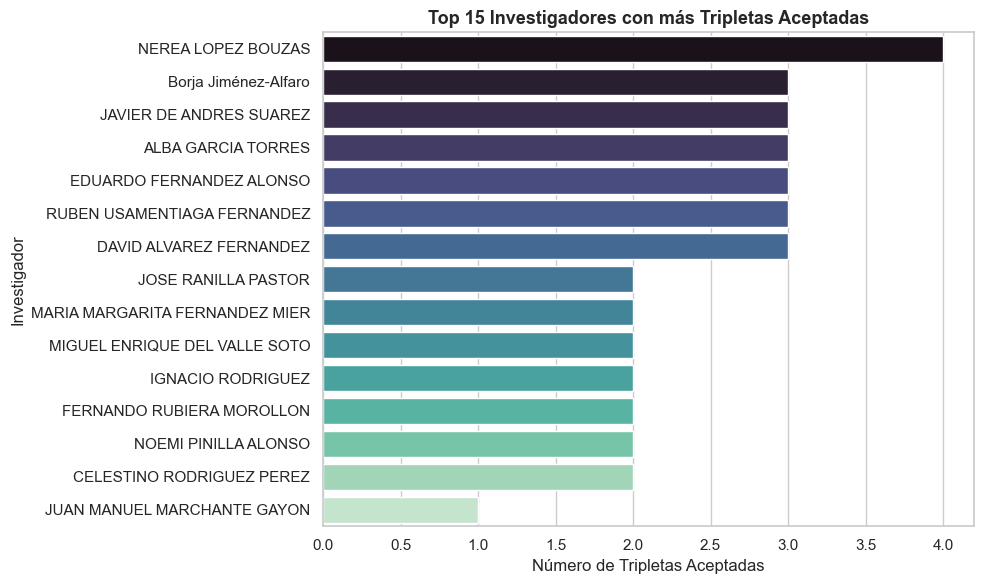

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_35902/2570132187.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_topics.values, y=top_topics.index, palette="rocket")


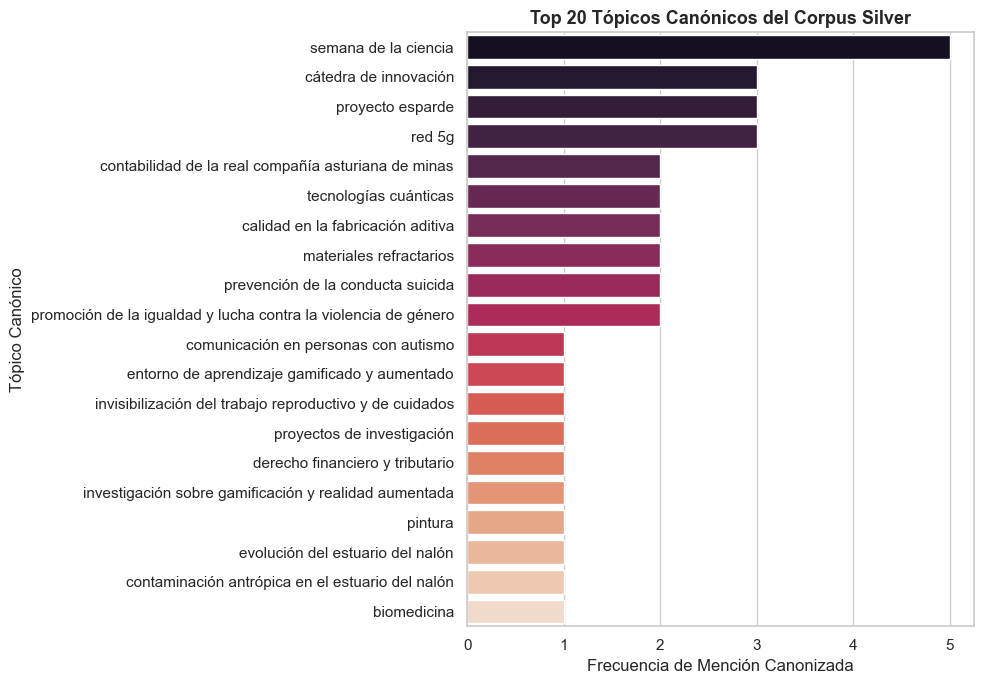

 RESUMEN DE EJECUCIÓN Y STATUS DE NOTICIAS
                           Conteo Absoluto  Porcentaje (%)
status                                                    
sin_tripletas_tras_filtro              192           63.37
sin_candidatos                          58           19.14
ok                                      53           17.49

 MÉTRICAS DE FILTRADO Y RETENCIÓN DEL PIPELINE
• Candidatos Raw Totales:          1.894
• Candidatos Tras Filtro:          1.481
  └─ Tasa de Reducción de Ruido:   21.81%
------------------------------------------------------------
• Tripletas Raw (LLM):               301
• Tripletas Aceptadas (Silver):       92
  └─ Tasa de Aceptación/Aprobación: 30.56%


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración global de visualización
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ==========================================
# 1. CANDIDATOS RAW VS FILTRADOS 
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot comparativo
df_cand_melt = df_noticias_pipeline.melt(
    id_vars=["news_id"],
    value_vars=["num_candidatos_raw", "num_candidatos_filtrados"],
    var_name="Fase",
    value_name="Cantidad",
)
df_cand_melt["Fase"] = df_cand_melt["Fase"].map(
    {
        "num_candidatos_raw": "Raw (Inicial)",
        "num_candidatos_filtrados": "Filtrados (Conservador)",
    }
)

sns.boxplot(
    data=df_cand_melt,
    x="Fase",
    y="Cantidad",
    palette="Set2",
    ax=axes[0],
    width=0.4,
)
axes[0].set_title(
    "Distribución de Candidatos por Noticia", fontweight="bold", fontsize=12
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Candidatos por Noticia")

# Subplot B: Histograma de reducción
sns.histplot(
    data=df_noticias_pipeline,
    x="num_candidatos_raw",
    color="skyblue",
    label="Raw",
    kde=True,
    ax=axes[1],
    alpha=0.5,
)
sns.histplot(
    data=df_noticias_pipeline,
    x="num_candidatos_filtrados",
    color="orange",
    label="Filtrados",
    kde=True,
    ax=axes[1],
    alpha=0.6,
)
axes[1].set_title(
    "Superposición de Densidad de Candidatos", fontweight="bold", fontsize=12
)
axes[1].set_xlabel("Número de Candidatos")
axes[1].set_ylabel("Frecuencia (Noticias)")
axes[1].legend()

plt.tight_layout()
plt.show()


# ==========================================
# 2. DISTRIBUCIÓN DE RELACIONES ACEPTADAS
# ==========================================
plt.figure(figsize=(9, 5))
order_rel = df_tripletas_aceptadas["relacion"].value_counts().index
ax_rel = sns.countplot(
    data=df_tripletas_aceptadas,
    y="relacion",
    order=order_rel,
    palette="viridis",
)

plt.title(
    "Distribución de Relaciones Aceptadas en el Corpus Silver",
    fontweight="bold",
    fontsize=13,
)
plt.xlabel("Cantidad de Tripletas")
plt.ylabel("Tipo de Relación")

# Anotación de totales sobre las barras
for p in ax_rel.patches:
    ax_rel.annotate(
        f"{int(p.get_width())}",
        (p.get_width(), p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()


# ==========================================
# 3. TOP INVESTIGADORES MÁS FRECUENTES
# ==========================================
plt.figure(figsize=(10, 6))
top_inv = df_tripletas_aceptadas["nombre_investigador"].value_counts().head(15)

sns.barplot(x=top_inv.values, y=top_inv.index, palette="mako")
plt.title(
    "Top 15 Investigadores con más Tripletas Aceptadas",
    fontweight="bold",
    fontsize=13,
)
plt.xlabel("Número de Tripletas Aceptadas")
plt.ylabel("Investigador")
plt.tight_layout()
plt.show()


# ==========================================
# 4. TOP TÓPICOS CANÓNICOS
# ==========================================
plt.figure(figsize=(10, 7))
top_topics = df_silver["topico_canonico"].value_counts().head(20)

sns.barplot(x=top_topics.values, y=top_topics.index, palette="rocket")
plt.title(
    "Top 20 Tópicos Canónicos del Corpus Silver", fontweight="bold", fontsize=13
)
plt.xlabel("Frecuencia de Mención Canonizada")
plt.ylabel("Tópico Canónico")
plt.tight_layout()
plt.show()



# Conteo absoluto y relativo de ejecuciones
df_status = df_noticias_pipeline["status"].value_counts().to_frame()
df_status.columns = ["Conteo Absoluto"]
df_status["Porcentaje (%)"] = (
    df_status["Conteo Absoluto"] / len(df_noticias_pipeline) * 100
).round(2)

# Tasas de reducción globales
cand_raw_total = df_noticias_pipeline["num_candidatos_raw"].sum()
cand_filt_total = df_noticias_pipeline["num_candidatos_filtrados"].sum()
tasa_filtrado_candidatos = (
    (1 - (cand_filt_total / cand_raw_total)) * 100
    if cand_raw_total > 0
    else 0
)

trip_raw_total = len(df_tripletas_raw)
trip_aceptadas_total = len(df_tripletas_aceptadas)
tasa_aceptacion_tripletas = (
    (trip_aceptadas_total / trip_raw_total) * 100 if trip_raw_total > 0 else 0
)

print("=" * 60)
print(" RESUMEN DE EJECUCIÓN Y STATUS DE NOTICIAS")
print("=" * 60)
print(df_status.to_string())
print("\n" + "=" * 60)
print(" MÉTRICAS DE FILTRADO Y RETENCIÓN DEL PIPELINE")
print("=" * 60)
print(
    f"• Candidatos Raw Totales:        {cand_raw_total:>7,d}".replace(",", ".")
)
print(
    f"• Candidatos Tras Filtro:        {cand_filt_total:>7,d}".replace(",", ".")
)
print(f"  └─ Tasa de Reducción de Ruido: {tasa_filtrado_candidatos:>7.2f}%")
print("-" * 60)
print(
    f"• Tripletas Raw (LLM):           {trip_raw_total:>7,d}".replace(",", ".")
)
print(
    f"• Tripletas Aceptadas (Silver):  {trip_aceptadas_total:>7,d}".replace(
        ",", "."
    )
)
print(f"  └─ Tasa de Aceptación/Aprobación: {tasa_aceptacion_tripletas:>5.2f}%")
print("=" * 60)

Vamos a ver que filtros son los que mas funcionan sobre neustras tripletas para el final. 

In [25]:
import pandas as pd

def auditar_descartes_silver_6_reglas(df_tripletas, df_roles, candidatos_por_noticia, diccionario_investigadores):
    RELACIONES_VALIDAS = {"LIDERA", "INVESTIGA_SOBRE", "DESARROLLA", "COLABORA_EN"}
    
    df_roles_clean = df_roles[['investigador_id', 'noticia_index', 'rol']].drop_duplicates(
        subset=['investigador_id', 'noticia_index']
    )
    df_work = df_tripletas.merge(df_roles_clean, on=['investigador_id', 'noticia_index'], how='left')
    
    total_raw = len(df_work)
    if total_raw == 0:
        return pd.DataFrame()

    descartes_grounding = 0      # Regla 1
    descartes_esquema = 0        # Regla 2
    descartes_lexico = 0         # Regla 3
    descartes_rol = 0            # Regla 4
    descartes_contexto = 0       # Regla 6
    
    indices_validos = []
    
    for idx, row in df_work.iterrows():
        # Regla 4: Role consistency
        fail_rol = row.get('rol') != 'INVESTIGADOR'
        
        # Regla 2: Closed-schema
        fail_esquema = row.get('relacion') not in RELACIONES_VALIDAS
        
        # Regla 3: Lexical support
        fail_lexico = not validar_soporte_lexico(str(row.get('topico', '')), str(row.get('evidencia', '')))
        
        # Regla 6: Context compatibility 
        info_inv = diccionario_investigadores.get(row['investigador_id'], {})
        fail_contexto = len(info_inv) == 0
        
        # Regla 1: Grounded selection
        noticia_idx = row['noticia_index']
        candidatos_noticia = candidatos_por_noticia.get(noticia_idx, [])
        tokens_nombre = [t for t in normalizar(info_inv.get('nombre_oficial', '')).split() if len(t) > 2]
        evidencia_norm = normalizar(str(row.get('evidencia', '')))
        mencionado = any(t in evidencia_norm for t in tokens_nombre)
        fail_grounding = not ((len(candidatos_noticia) <= 3) or mencionado)

        # Contadores individuales
        if fail_rol: descartes_rol += 1
        if fail_esquema: descartes_esquema += 1
        if fail_lexico: descartes_lexico += 1
        if fail_contexto: descartes_contexto += 1
        if fail_grounding: descartes_grounding += 1

        if not (fail_rol or fail_esquema or fail_lexico or fail_contexto or fail_grounding):
            indices_validos.append(idx)

    # Regla 5: Deduplicación
    df_filtradas = df_work.loc[indices_validos]
    df_dedup = df_filtradas.drop_duplicates(subset=['investigador_id', 'relacion', 'topico', 'noticia_index'])
    descartes_duplicados = len(df_filtradas) - len(df_dedup)

    metricas = [
        {"Regla de Filtrado (Paper)": "1. Unambiguous/Grounded Selection", "Descartes (Absoluto)": descartes_grounding},
        {"Regla de Filtrado (Paper)": "2. Closed-Schema Relation Validity", "Descartes (Absoluto)": descartes_esquema},
        {"Regla de Filtrado (Paper)": "3. Evidence-Topic Lexical Support", "Descartes (Absoluto)": descartes_lexico},
        {"Regla de Filtrado (Paper)": "4. Role Consistency", "Descartes (Absoluto)": descartes_rol},
        {"Regla de Filtrado (Paper)": "5. Internal Coherence (Duplicates)", "Descartes (Absoluto)": descartes_duplicados},
        {"Regla de Filtrado (Paper)": "6. Context Compatibility", "Descartes (Absoluto)": descartes_contexto},
    ]

    df_resumen = pd.DataFrame(metricas)
    df_resumen["% sobre Total Raw"] = (df_resumen["Descartes (Absoluto)"] / total_raw * 100).round(2)
    return df_resumen.sort_values(by="Descartes (Absoluto)", ascending=False).reset_index(drop=True)

df_tabla_descartes = auditar_descartes_silver_6_reglas(
    df_tripletas, df_roles, candidatos_por_noticia, diccionario_investigadores
)

In [27]:
df_tabla_descartes

,Regla de Filtrado (Paper),Descartes (Absoluto),% sobre Total Raw
0,1. Unambiguous/Grounded Selection,131,43.52
1,3. Evidence-Topic Lexical Support,122,40.53
2,4. Role Consistency,4,1.33
3,5. Internal Coherence (Duplicates),1,0.33
4,2. Closed-Schema Relation Validity,0,0.00
5,6. Context Compatibility,0,0.00


In [26]:

os.makedirs("./datos", exist_ok=True)

# Exportar todas las tripletas generadas por el LLM
df_tripletas.to_csv(
    "./datos/tripletas_generadas.csv",
    index=False,
    encoding="utf-8-sig"
)

# Exportar las tripletas aceptadas en el dataset Silver
df_silver.to_csv(
    "./datos/tripletas_aceptadas.csv",
    index=False,
    encoding="utf-8-sig"
)

print(f"Tripletas generadas exportadas: {len(df_tripletas)}")
print(f"Tripletas aceptadas exportadas: {len(df_silver)}")

Tripletas generadas exportadas: 301
Tripletas aceptadas exportadas: 92
